### Q-learning model

In [25]:
# Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Eviroment aanmaken
env = gym.make('Taxi-v3')

# Q-table aanmaken
q_table = np.zeros((env.observation_space.n,
                    env.action_space.n))

# zeros: Alle waarden in de Q-table worden geïnitialiseerd op 0
# observation_space.n: Het aantal mogelijke staten in de omgeving (500)
# action_space.n: Het aantal mogelijke acties die de agent kan nemen (6)

# Hyperparameters instellen
alpha = 0.1  # Leerpercentage: Hoe snel de agent leert van nieuwe ervaringen
gamma = 0.6  # Kortingsfactor: Hoeveel waarde hecht de agent aan toekomstige beloningen
epsilon = 0.1  # Exploratiepercentage: Kans dat de agent een willekeurige actie kiest in plaats van de actie met de hoogste Q-waarde
epsilon_decay = 0.99  # Decay factor voor epsilon: Hoeveel epsilon afneemt na elke episode
epsilon_min = 0.01  # Minimum waarde voor epsilon: De agent zal altijd minstens deze kans hebben om te exploreren
episodes = 1000  # Aantal trainingsepisodes: Hoeveel keer de agent de omgeving zal verkennen en leren

In [26]:
rewards_per_episode = []

# Training loop
for episode in range(episodes):

    state, info = env.reset()
    done = False

    total_reward = 0

    while not done:

        # epsilon-greedy keuze
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # actie uitvoeren
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Q-update
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])

        new_value = old_value + alpha * (
            reward + gamma * next_max - old_value
        )

        q_table[state, action] = new_value

        state = next_state

        # reward optellen
        total_reward += reward

    rewards_per_episode.append(total_reward)

    # epsilon verlagen
    epsilon = max(epsilon_min,
                  epsilon * epsilon_decay)

In [27]:
average_rewards = []

window_size = 100

for i in range(len(rewards_per_episode)):
    start = max(0, i - window_size)
    average = np.mean(rewards_per_episode[start:i+1])
    average_rewards.append(average)

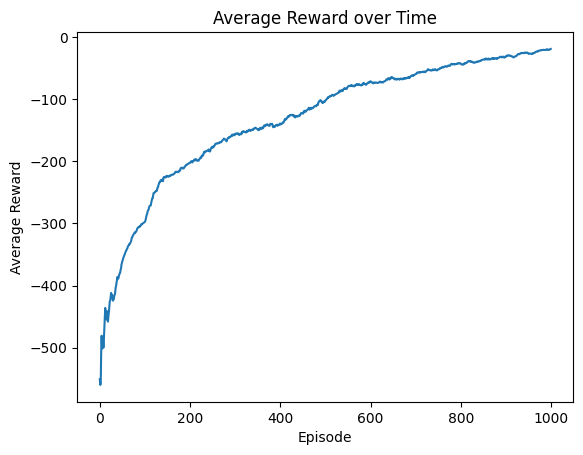

In [33]:
plt.plot(average_rewards)

plt.xlabel('Episode')
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")

plt.show()

In [31]:
state, info = env.reset()
done = False

while not done:

    action = np.argmax(q_table[state])

    state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    env.render()